In [1]:
!pip install data

  Preparing metadata (setup.py) ... done
  Created wheel for data: filename=data-0.4-py3-none-any.whl size=7270 sha256=6157ca2c3bbbf9a7846243d01ab0ae9e0eebfb449d489955be889cded45ba715
  Stored in directory: /root/.cache/pip/wheels/b8/4b/57/d9c76c93455778ccb698ad058ce121d59be8b9646896292e41
Successfully built data


In [3]:
# 1) Tạo data/processed/train.npz, eval.npz
subprocess.run([sys.executable, "/kaggle/input/datasets/daohhdg/split-data/split_data.py"], cwd=REPO_ROOT, check=True)

# 2) Tách val, chuẩn hoá bằng thống kê train, đưa lên device
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

def _get(d, k):  # data có thể là dict hoặc object
    return d[k] if isinstance(d, dict) else getattr(d, k)
X_tr, y_tr = _get(data, "X_tr"), _get(data, "y_tr")
X_val, y_val = _get(data, "X_val"), _get(data, "y_val")
X_eval = _get(data, "X_eval")

# 3) Kích thước + mốc "đoán đa số"
print("X_tr", tuple(X_tr.shape), "| X_val", tuple(X_val.shape), "| X_eval", tuple(X_eval.shape))
majority_acc = torch.bincount(y_val.long()).max().item() / len(y_val)
print(f"Majority-class acc trên val = {majority_acc:.4f} (kỳ vọng ≈ 0.4876)")

# 4) 10 cột số (đầu tiên) trên X_tr phải có mean ≈ 0, std ≈ 1
mu, sd = X_tr[:, :10].mean(0), X_tr[:, :10].std(0)
print("max |mean| =", mu.abs().max().item(), "| max |std-1| =", (sd - 1).abs().max().item())
assert mu.abs().max() < 1e-2 and (sd - 1).abs().max() < 1e-2, "10 cột số chưa được chuẩn hoá đúng"

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> /kaggle/working/data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> /kaggle/working/data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876
X_tr=(371847, 54), X_val=(92962, 54), X_eval=(116203, 54)
majority-class baseline on val (label 1): acc = 0.4876
X_tr (371847, 54) | X_val (92962, 54) | X_eval (116203, 54)
Majority-class acc trên val = 0.4876 (kỳ vọng ≈ 0.4876)
max |mean| = 0.0003210586728528142 | max |std-1| = 0.00010818243026733398


In [2]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
import numpy as np, torch

REPO_ROOT = "/kaggle/input/datasets/daohhdg/track4/K4-Track4-Day1-Neuralnetwork"     # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = "/kaggle/working/"        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)
# Colab: nếu chưa có repo, bỏ comment 2 dòng dưới, rồi đặt REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
# !git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

device = "cuda" if torch.cuda.is_available() else ("mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "no CUDA GPU")
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

import sys
import os

CODE_DIR = "/kaggle/input/datasets/daohhdg/track4/K4-Track4-Day1-Neuralnetwork/submission_02670/code"

sys.path.insert(0, CODE_DIR)

# Xóa module data đã bị import nhầm trước đó
sys.modules.pop("data", None)
from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

torch 2.11.0+cpu | device: cpu | no CUDA GPU


Số tham số: 47879
logits shape: (8, 7)
loss bước 0 (val) = 2.3776 | ln 7 = 1.9459
loss 20 mẫu: bước 0 = 1.9668 -> bước cuối = 0.000266


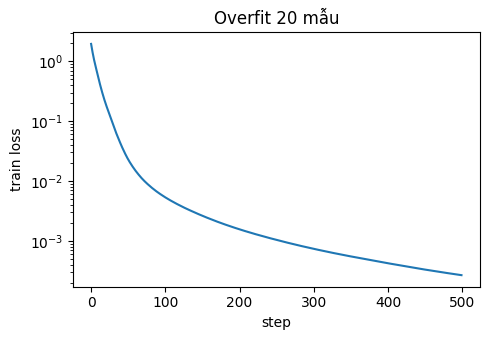

net.0.weight                   grad_norm = 0.582328
net.0.bias                     grad_norm = 0.383371
net.2.weight                   grad_norm = 2.371798
net.2.bias                     grad_norm = 0.498173
net.4.weight                   grad_norm = 2.078366
net.4.bias                     grad_norm = 0.606071


In [4]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# TODO 1: M-base + kiểm tra số tham số
set_seed(42)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
assert count_params(model) == EXPECTED_PARAMS[(256, 128)]
print("Số tham số:", count_params(model))

# TODO 2: forward một lô ngẫu nhiên (8, 54)
model.eval()
with torch.no_grad():
    logits = model(torch.randn(8, 54, device=device))
print("logits shape:", tuple(logits.shape))
assert logits.shape == (8, 7)

# TODO 3: loss bước 0 trên val (eval mode) ≈ ln 7
with torch.no_grad():
    loss0 = F.cross_entropy(model(X_val), y_val.long()).item()
print(f"loss bước 0 (val) = {loss0:.4f} | ln 7 = {np.log(7):.4f}")

# TODO 4: quá khớp 20 mẫu (không dropout)
set_seed(0)
m20 = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
m20.train()
opt20 = torch.optim.Adam(m20.parameters(), lr=1e-3)
x20, y20 = X_tr[:20], y_tr[:20].long()
losses20 = []
for step in range(500):
    opt20.zero_grad()
    l = F.cross_entropy(m20(x20), y20)
    l.backward()
    opt20.step()
    losses20.append(l.item())
print(f"loss 20 mẫu: bước 0 = {losses20[0]:.4f} -> bước cuối = {losses20[-1]:.6f}")
assert losses20[-1] < 0.05, "Không quá khớp được 20 mẫu -> kiểm tra model/loss/optimizer"
plt.figure(figsize=(5, 3.5)); plt.plot(losses20); plt.yscale("log")
plt.xlabel("step"); plt.ylabel("train loss"); plt.title("Overfit 20 mẫu"); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/figures/overfit20.png", dpi=150); plt.show()

# TODO 5: grad norm từng tham số sau một lần backward
model.train(); model.zero_grad()
F.cross_entropy(model(X_tr[:512]), y_tr[:512].long()).backward()
for n, p in model.named_parameters():
    assert p.grad is not None, f"{n}: grad = None"
    gn = p.grad.norm().item()
    print(f"{n:30s} grad_norm = {gn:.6f}")
    assert gn > 0, f"{n}: grad = 0"

In [5]:
S = lambda r: r["summary"]
runs = {}   # exp_id -> (cfg, result), dùng lại ở Part 3 và 4

# TODO 1: chọn lr bằng VAL
lr_table = {}
for lr in [0.01, 0.03, 0.05, 0.1]:
    c = {**DEFAULT_CFG, "lr": lr, "seed": 0, "exp_id": f"lrsweep-{lr}"}
    r = run_experiment(c, data)
    lr_table[lr] = S(r)["val_macro_f1"]
    print(f"lr={lr:<6} val_macro_f1={lr_table[lr]:.4f}")
best_lr = max(lr_table, key=lr_table.get)
print("lr được chọn:", best_lr)

# TODO 2: cfg baseline
cfg = {**DEFAULT_CFG, "lr": best_lr}

# TODO 3 + 4: chạy baseline nhiều seed, lưu kết quả + ảnh
base_results = []
for s in [0, 1, 2]:
    c = {**cfg, "seed": s, "exp_id": f"base-s{s}"}
    result = run_experiment(c, data)
    save_result(result, f"{OUT_DIR}/results")
    plot_run(result, f"{OUT_DIR}/figures/{c['exp_id']}.png")
    runs[c["exp_id"]] = (c, result)
    base_results.append(result)
    print(c["exp_id"], S(result))

# TODO 5: mean ± std qua các seed, ngưỡng nhiễu 2σ
f1s  = np.array([S(r)["val_macro_f1"] for r in base_results])
accs = np.array([S(r)["val_acc"] for r in base_results])
base_f1_mean, base_f1_std = f1s.mean(), f1s.std(ddof=1)
print(f"val_macro_f1 = {f1s.mean():.4f} ± {f1s.std(ddof=1):.4f}")
print(f"val_acc      = {accs.mean():.4f} ± {accs.std(ddof=1):.4f}")
print(f"Ngưỡng nhiễu 2σ (macro-F1) = {2 * base_f1_std:.4f}")

lr=0.01   val_macro_f1=0.7719
lr=0.03   val_macro_f1=0.8264
lr=0.05   val_macro_f1=0.8455
lr=0.1    val_macro_f1=0.8594
lr được chọn: 0.1
base-s0 {'step0_loss': 2.248767732227452, 'best_val_loss': 0.22818079997492915, 'best_epoch': 20, 'final_train_loss': 0.2074628726250269, 'final_val_loss': 0.22818079997492915, 'val_acc': 0.9083496332168579, 'val_macro_f1': 0.8594347781739364, 'time_per_epoch_s': 32.41561414874999, 'peak_mem_MB': 0.0, 'diverged': False}
base-s1 {'step0_loss': 2.191880469801186, 'best_val_loss': 0.2242939567213786, 'best_epoch': 19, 'final_train_loss': 0.2079682995391991, 'final_val_loss': 0.23293172430952117, 'val_acc': 0.9101998805999756, 'val_macro_f1': 0.8595848926203519, 'time_per_epoch_s': 31.167582884450006, 'peak_mem_MB': 0.0, 'diverged': False}
base-s2 {'step0_loss': 1.7958566612339797, 'best_val_loss': 0.22676702110947047, 'best_epoch': 20, 'final_train_loss': 0.20707301915133694, 'final_val_loss': 0.22676702110947047, 'val_acc': 0.9078118205070496, 'val_mac

In [6]:
# Thí nghiệm mẫu: dropout 0.3 (chỉ đổi MỘT yếu tố so với baseline). Đổi cfg để làm thí nghiệm khác.
exp_cfg = {**cfg, "seed": 0, "exp_id": "dropout-0.3", "group": "dropout",
           "description": "Baseline + dropout 0.3", "dropout": 0.3}
result_exp = run_experiment(exp_cfg, data)
save_result(result_exp, f"{OUT_DIR}/results")
plot_run(result_exp, f"{OUT_DIR}/figures/{exp_cfg['exp_id']}.png")
runs[exp_cfg["exp_id"]] = (exp_cfg, result_exp)

print("Thí nghiệm:", S(result_exp))
print("Baseline (seed 0):", S(base_results[0]))
delta = S(result_exp)["val_macro_f1"] - base_f1_mean
print(f"Δ macro-F1 so với baseline mean = {delta:+.4f} | 2σ = {2 * base_f1_std:.4f} -> "
      + ("VƯỢT nhiễu" if abs(delta) > 2 * base_f1_std else "trong ngưỡng nhiễu"))

Thí nghiệm: {'step0_loss': 2.248767732227452, 'best_val_loss': 0.31652688522177397, 'best_epoch': 19, 'final_train_loss': 0.31004619640377545, 'final_val_loss': 0.3176655739257936, 'val_acc': 0.8691293001174927, 'val_macro_f1': 0.7797121244190016, 'time_per_epoch_s': 61.61811164979997, 'peak_mem_MB': 0.0, 'diverged': False}
Baseline (seed 0): {'step0_loss': 2.248767732227452, 'best_val_loss': 0.22818079997492915, 'best_epoch': 20, 'final_train_loss': 0.2074628726250269, 'final_val_loss': 0.22818079997492915, 'val_acc': 0.9083496332168579, 'val_macro_f1': 0.8594347781739364, 'time_per_epoch_s': 32.41561414874999, 'peak_mem_MB': 0.0, 'diverged': False}
Δ macro-F1 so với baseline mean = -0.0805 | 2σ = 0.0026 -> VƯỢT nhiễu


In [7]:
plot_compare([base_results[0], result_exp], "val_loss", f"{OUT_DIR}/figures/compare_dropout.png")

In [21]:
import glob

print(glob.glob("/kaggle/input/**/covtype.csv.gz", recursive=True))
print(glob.glob("/kaggle/input/**/split_metadata.csv", recursive=True))

[]
['/kaggle/input/datasets/daohhdg/track4/K4-Track4-Day1-Neuralnetwork/data/split_metadata.csv']


In [23]:
# TODO 1: chọn cấu hình cuối theo VAL macro-F1 (trong các run đã làm)
best_id = max(runs, key=lambda k: S(runs[k][1])["val_macro_f1"])
cfg_final, result_final = runs[best_id]
print("Cấu hình cuối:", best_id, S(result_final))

# TODO 2: dự đoán trên toàn bộ eval

old_run = subprocess.run
subprocess.run = lambda cmd, *a, **k: (
    subprocess.CompletedProcess(cmd, 0)
    if "evaluate.py" in str(cmd)
    else old_run(cmd, *a, **k)
)

final_eval(
    cfg_final,
    result_final,
    data,
    f"{OUT_DIR}/predictions_eval.csv"
)

cfg_b, result_b = runs["base-s0"]

final_eval(
    cfg_b,
    result_b,
    data,
    f"{OUT_DIR}/predictions_eval_baseline.csv"
)

subprocess.run = old_run


# TODO 3: chấm điểm

REPO_ROOT = "/kaggle/input/datasets/daohhdg/track4/K4-Track4-Day1-Neuralnetwork"
EVALUATE_SCRIPT = f"{REPO_ROOT}/scripts/evaluate.py"

DATA = "/kaggle/input/datasets/daohhdg/track4/K4-Track4-Day1-Neuralnetwork/data/covtype.csv"
META = "/kaggle/input/datasets/daohhdg/track4/K4-Track4-Day1-Neuralnetwork/data/split_metadata.csv"

for pred, out in [
    ("predictions_eval.csv", "eval_result.json"),
    ("predictions_eval_baseline.csv", "eval_result_baseline.json")
]:
    subprocess.run([
        sys.executable,
        EVALUATE_SCRIPT,
        "--pred", os.path.abspath(f"{OUT_DIR}/{pred}"),
        "--out", os.path.abspath(f"{OUT_DIR}/{out}"),
        "--data", DATA,
        "--meta", META,
    ], cwd=REPO_ROOT, check=True)

# TODO 4: đọc kết quả
eval_final = json.load(open(f"{OUT_DIR}/eval_result.json"))
eval_base  = json.load(open(f"{OUT_DIR}/eval_result_baseline.json"))
for name, e in [("FINAL", eval_final), ("BASELINE", eval_base)]:
    print(name, "| accuracy =", e.get("accuracy"), "| macro_f1 =", e.get("macro_f1"))

Cấu hình cuối: base-s2 {'step0_loss': 1.7958566612339797, 'best_val_loss': 0.22676702110947047, 'best_epoch': 20, 'final_train_loss': 0.20707301915133694, 'final_val_loss': 0.22676702110947047, 'val_acc': 0.9078118205070496, 'val_macro_f1': 0.8617169314012649, 'time_per_epoch_s': 31.655910781199953, 'peak_mem_MB': 0.0, 'diverged': False}
n_eval = 116203
accuracy = 0.9059
macro_f1 = 0.8645   <- chi so chinh

class  support  precision  recall    f1
  0    42368     0.8825  0.9263  0.9039
  1    56661     0.9393  0.8967  0.9175
  2     7151     0.9001  0.9070  0.9035
  3      549     0.7575  0.8707  0.8102
  4     1899     0.7509  0.7873  0.7686
  5     3473     0.8191  0.8290  0.8240
  6     4102     0.9022  0.9464  0.9237

confusion matrix (rows=true, cols=pred):
       0      1     2    3     4     5     6
0  39244   2697     0    0    61    12   354
1   4977  50806   211    3   400   197    67
2      3    129  6486  119    26   388     0
3      0      0    44  478     0    27     0
4 

Các khoá trong eval_result.json: ['n_eval', 'accuracy', 'macro_f1', 'per_class', 'confusion_matrix']


,cls,support,precision,recall,f1
0,0,42368,0.882502,0.926265,0.903854
1,1,56661,0.939321,0.896666,0.917498
2,2,7151,0.900083,0.907006,0.903531
3,3,549,0.757528,0.870674,0.810169
4,4,1899,0.750879,0.787256,0.768638
5,5,3473,0.819061,0.828966,0.823984
6,6,4102,0.902161,0.946368,0.923736


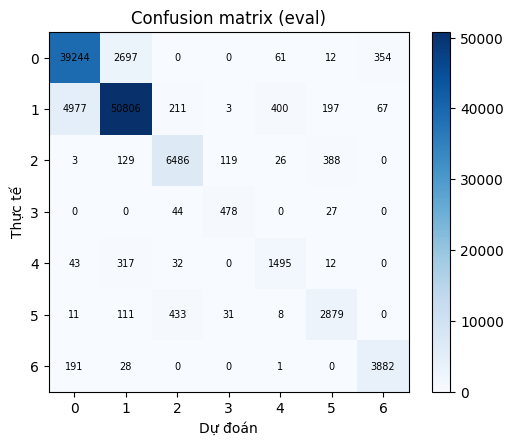

Recall theo lớp: [0.926 0.897 0.907 0.871 0.787 0.829 0.946] -> lớp khó nhất: 4


In [24]:
import pandas as pd
# Bảng precision/recall/F1 theo lớp + ma trận nhầm lẫn (tên khoá tuỳ evaluate.py; in toàn bộ nếu không khớp)
print("Các khoá trong eval_result.json:", list(eval_final.keys()))
per_class = eval_final.get("per_class")
if per_class is not None:
    df_pc = pd.DataFrame(per_class)
    display(df_pc)
cm = eval_final.get("confusion_matrix")
if cm is not None:
    cm = np.array(cm)
    plt.figure(figsize=(5.5, 4.5)); plt.imshow(cm, cmap="Blues"); plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=7)
    plt.xlabel("Dự đoán"); plt.ylabel("Thực tế"); plt.title("Confusion matrix (eval)"); plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/figures/confusion_matrix.png", dpi=150); plt.show()
    recall = cm.diagonal() / cm.sum(1)
    print("Recall theo lớp:", np.round(recall, 3), "-> lớp khó nhất:", int(recall.argmin()))

In [25]:
# TODO 1: gom kết quả
results = load_results(f"{OUT_DIR}/results")
rows = [to_row(r) for r in results]

# TODO 2: ghi experiments.xlsx từ template
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx")

# TODO 3: sheet Seeds + nhận xét Summary
from openpyxl import load_workbook
wb = load_workbook(f"{OUT_DIR}/experiments.xlsx")
ws = wb["Seeds"] if "Seeds" in wb.sheetnames else wb.create_sheet("Seeds")
ws.append(["exp_id", "seed", "val_macro_f1", "val_acc"])
for s, r in zip([0, 1, 2], base_results):
    ws.append([f"base-s{s}", s, S(r)["val_macro_f1"], S(r)["val_acc"]])
ws.append(["mean", "", float(f1s.mean()), float(accs.mean())])
ws.append(["std", "", float(f1s.std(ddof=1)), float(accs.std(ddof=1))])
ws = wb["Summary"] if "Summary" in wb.sheetnames else wb.create_sheet("Summary")
ws["A1"] = "Nhận xét (tự điền): ..."   # <- viết nhận xét của bạn ở đây
wb.save(f"{OUT_DIR}/experiments.xlsx")